# Docking two protomers against a FRET distance network

You have a handful of measured inter-subunit distances and two copies of a
protein that you believe form a dimer. Where does the second copy sit relative
to the first?

That is the docking question, and in FRET it is posed like this: each
measurement is a mean donor--acceptor distance between a dye at one site on
protomer A and a dye at one site on protomer B. Each dye is not a point but a
cloud -- the accessible volume of the linker -- so a "distance" is a statistic
of two clouds, not of two atoms. Move protomer B, and every one of those
statistics changes. Docking is the search for the placement of B that
reproduces them all.

The protein here is **BmrA**, a bacterial ABC transporter that works as a
homodimer. `doc/workshop/workshop.py` keeps two states of it: the compact,
outward-facing structure 6R72 (`"closed"`) and the inward-facing cryo-EM
structure 8QOE (`"open"`), each cut down to chains A and B -- one dimer.

What this notebook does, in order:

1. build a network of ten inter-protomer site pairs and compute their
   accessible-volume distances in the closed state;
2. turn those into a synthetic measurement set with realistic noise;
3. ask whether the network *discriminates*: does a wrong placement score
   worse, and by how much;
4. run the library's rigid-body docking and measure how far from the answer a
   run can start and still get back;
5. report the per-distance deviations and the RMSD to the deposited
   arrangement, before and after.

Every number below is produced by the cell that prints it. Where the result is
a limitation rather than a success, it is stated as one.

In [1]:
%matplotlib inline

import json
import pathlib
import sys
import tempfile
import time

import numpy as np
import matplotlib.pyplot as plt

# The notebook is normally executed with its own directory as the working
# directory, but that is a convention, not a guarantee -- so find workshop.py
# rather than assume it is next door.
for _candidate in (pathlib.Path.cwd(), pathlib.Path.cwd() / "doc" / "workshop",
                   pathlib.Path.cwd().parent, pathlib.Path.cwd().parent.parent):
    if (_candidate / "workshop.py").is_file():
        sys.path.insert(0, str(_candidate.resolve()))
        break
else:
    raise RuntimeError("workshop.py not found; run this from doc/workshop")

import workshop as ws

import IMP
import IMP.algebra
import IMP.atom
import IMP.bff

IMP.set_log_level(IMP.SILENT)
T_START = time.time()

WORK = pathlib.Path(tempfile.mkdtemp(prefix="bmra_docking_"))
print("IMP.bff from", pathlib.Path(IMP.bff.__file__).parent)
print("scratch directory", WORK)

IMP.bff from /Users/tpeulen/dev/imp/cmake-build-arm64/lib/IMP/bff
scratch directory /var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/bmra_docking_s3sbv3_6


## Two rigid bodies

The docking engine works on rigid bodies, and one rigid body is one PDB file:
`IMP.bff.create_docking_assembly` reads each path, makes it a body, and the
`body_id` field of each labelling position says which body that position rides
on. So the first thing to do is cut the dimer in two.

The split is a real modelling decision, not bookkeeping. It asserts that each
protomer keeps its internal geometry and that only their relative placement is
unknown. For BmrA that assertion is already an approximation -- the
nucleotide-binding domains move relative to the transmembrane domains between
the two states -- and the notebook comes back to it at the end.

In [2]:
def split_chain(source, chain, destination):
    # One chain of a PDB as its own file: one rigid body for the docking.
    kept = [line for line in pathlib.Path(source).read_text().splitlines(keepends=True)
            if line.startswith(("ATOM", "TER")) and line[21:22] == chain]
    kept.append("END\n")
    pathlib.Path(destination).write_text("".join(kept))
    return str(destination)


closed_dimer = ws.single_dimer("closed")
open_dimer = ws.single_dimer("open")

PROTOMER_A = split_chain(closed_dimer, "A", WORK / "protomer_A.pdb")
PROTOMER_B = split_chain(closed_dimer, "B", WORK / "protomer_B.pdb")

for label, path in (("dimer  ", closed_dimer), ("body 0 (chain A)", PROTOMER_A),
                    ("body 1 (chain B)", PROTOMER_B)):
    n = sum(1 for line in pathlib.Path(path).read_text().splitlines()
            if line.startswith("ATOM"))
    print("%-18s %6d atoms  %s" % (label, n, pathlib.Path(path).name))

dimer                8788 atoms  BmrA_closed.pdb
body 0 (chain A)     4396 atoms  protomer_A.pdb
body 1 (chain B)     4392 atoms  protomer_B.pdb


## The network

A network is a set of site pairs, each pair one residue on chain A carrying the
donor and one residue on chain B carrying the acceptor. Two things decide
whether a pair is worth measuring:

* **The distance has to be in range.** Transfer efficiency is
  $E = 1/(1 + (R/R_0)^6)$, so with $R_0 = 52$ Å a 25 Å distance gives
  $E = 0.98$ and a 95 Å distance gives $E = 0.03$. Neither number moves when
  the structure does. Useful pairs sit roughly between 30 and 80 Å.
* **The dye has to have somewhere to go.** `ws.av` raises `EmptyVolume` when
  the accessible volume of a site comes back empty. That is not a short
  distance, it is *no* distance, and a site like that has to be dropped rather
  than fudged.

The ten pairs below were picked from a scan over surface positions spread along
the protomer -- residues 60 and 220 in the transmembrane region, 290 to 520
towards and inside the nucleotide-binding domain -- so that the network
constrains more than one direction. A network whose pairs all run parallel
pins down one coordinate and leaves the other five free, however precise each
individual measurement is.

The volumes are computed on the *whole dimer*, not on the isolated protomer: a
dye at the subunit interface is occluded by the partner chain, and that
occlusion is part of the distance.

In [3]:
CLEARANCE = 7.0          # allowed_sphere_radius, A -- see the note below
NOISE = 0.06             # relative error of the synthetic measurements

PAIRS = [("A", 410, "B", 220), ("A", 60, "B", 290), ("A", 470, "B", 220),
         ("A", 220, "B", 520), ("A", 60, "B", 60), ("A", 520, "B", 350),
         ("A", 350, "B", 410), ("A", 520, "B", 520), ("A", 470, "B", 290),
         ("A", 350, "B", 60)]

DYE_OF_CHAIN = {"A": "Alexa488", "B": "Alexa647"}
SITES = sorted({(p[0], p[1]) for p in PAIRS} | {(p[2], p[3]) for p in PAIRS})

site_name = lambda chain, resi: "%s%d" % (chain, resi)
pair_name = lambda p: "%s%d_%s%d" % p

volume = {}
for chain, resi in SITES:
    volume[(chain, resi)] = ws.av(closed_dimer, chain, resi,
                                  DYE_OF_CHAIN[chain],
                                  allowed_sphere_radius=CLEARANCE)

helper_distance = {p: ws.rda_e(volume[(p[0], p[1])], volume[(p[2], p[3])])
                   for p in PAIRS}

print("%-14s %-10s %-10s %8s %8s" % ("pair", "donor", "acceptor", "<RDA>_E", "E"))
for p in PAIRS:
    d = helper_distance[p]
    print("%-14s %-10s %-10s %8.2f %8.3f"
          % (pair_name(p), site_name(p[0], p[1]), site_name(p[2], p[3]),
             d, ws.efficiency(d)))
print("\n%d sites, %d pairs, all volumes non-empty" % (len(SITES), len(PAIRS)))

pair           donor      acceptor    <RDA>_E        E
A410_B220      A410       B220          30.60    0.960
A60_B290       A60        B290          32.74    0.941
A470_B220      A470       B220          38.01    0.868
A220_B520      A220       B520          42.13    0.780
A60_B60        A60        B60           46.51    0.661
A520_B350      A520       B350          47.68    0.627
A350_B410      A350       B410          55.03    0.416
A520_B520      A520       B520          56.13    0.387
A470_B290      A470       B290          63.73    0.228
A350_B60       A350       B60           77.54    0.083

12 sites, 10 pairs, all volumes non-empty


`<RDA>_E` is the distance that reproduces the mean transfer efficiency of the
two clouds. It is what a FRET experiment reports, and it is not the mean of the
distance distribution -- for broad volumes the two differ by several Ångström.
Mixing the two conventions is one of the commonest ways to get a structure that
is wrong by more than its stated error bar, which is why the `fps.json` written
below names the convention explicitly (`"distance_type": "RDAMeanE"`).

A word on `allowed_sphere_radius`, set to 7 Å here. It is the free sphere the
search is allowed around the attachment atom. The path search inflates every
obstacle by half the linker width, so at a tight site the source voxel gets
walled in and the volume comes back empty even though a real dye would fit. The
two doors onto an accessible volume in this library do not agree on a default
-- `ws.av` strips the attachment residue's own side chain, the `fps.json` route
strips only what its `strip_mask` says -- so both are spelled out below and
given the same value. If you change one, change the other, or the table and the
docking will be computing different distances.

## The labelling file

Everything the docking engine needs about the dyes lives in one JSON document:
a `Positions` section (where each dye hangs, with the geometry of its linker),
a `Distances` section (what was measured, with its error bars and its distance
convention), and a `χ²` section naming score sets -- subsets of the distances
that can be scored together.

`IMP.bff.score_structures` reads that document against a list of structures and
returns the per-pair table: measured value, model value, and the asymmetric
$\chi^2$ of each pair. Run against the deposited arrangement it is the sanity
check you do before anything else -- it says whether the file resolves against
the structures at all.

In [4]:
POSITIONS = {}
for chain, resi in SITES:
    geometry = ws.DYES[DYE_OF_CHAIN[chain]]
    POSITIONS[site_name(chain, resi)] = {
        "chain_identifier": chain,
        "residue_seq_number": resi,
        "atom_name": "CB",
        "simulation_type": "AV1",
        "linker_length": geometry["linker_length"],
        "linker_width": geometry["linker_width"],
        "radius1": geometry["av1_radius"],
        "radius2": 0.0,
        "radius3": 0.0,
        "simulation_grid_resolution": 1.5,
        "allowed_sphere_radius": CLEARANCE,
        # the attachment residue's own side chain is not an obstacle for its
        # own dye; IMP.bff spells that selection for us
        "strip_mask": IMP.bff.default_strip_mask(chain, resi, "CB"),
        "body_id": 0 if chain == "A" else 1,
    }


def write_fps(path, distances):
    # An fps.json for our network, with the given distances in Angstrom.
    section = {}
    for p in PAIRS:
        value = float(distances[p])
        section[pair_name(p)] = {
            "position1_name": site_name(p[0], p[1]),
            "position2_name": site_name(p[2], p[3]),
            "distance": round(value, 2),
            "distance_type": "RDAMeanE",
            "Forster_radius": ws.R0,
            "error_neg": round(NOISE * value, 2),
            "error_pos": round(NOISE * value, 2),
        }
    document = {"Positions": POSITIONS, "Distances": section,
                "χ²": {"all": {"distances": sorted(section)}}}
    pathlib.Path(path).write_text(json.dumps(document, indent=1))
    return str(path)


probe_file = write_fps(WORK / "probe.fps.json", helper_distance)
probe = IMP.bff.score_structures([PROTOMER_A, PROTOMER_B], probe_file, "all",
                                 False, 6.0, "", "olga", 1.0)
engine_distance = {p: [q for q in probe.pairs if q.name == pair_name(p)][0].distance_model
                   for p in PAIRS}

print("%-14s %10s %10s %8s" % ("pair", "ws.av", "engine", "diff"))
for p in PAIRS:
    print("%-14s %10.2f %10.2f %8.2f"
          % (pair_name(p), helper_distance[p], engine_distance[p],
             engine_distance[p] - helper_distance[p]))
deltas = np.array([engine_distance[p] - helper_distance[p] for p in PAIRS])
print("\nmean |difference| %.2f A, largest %.2f A"
      % (np.abs(deltas).mean(), np.abs(deltas).max()))

pair                ws.av     engine     diff
A410_B220           30.60      30.38    -0.22
A60_B290            32.74      32.37    -0.37
A470_B220           38.01      37.39    -0.62
A220_B520           42.13      42.66     0.53
A60_B60             46.51      45.20    -1.31
A520_B350           47.68      47.53    -0.15
A350_B410           55.03      58.40     3.36
A520_B520           56.13      55.42    -0.71
A470_B290           63.73      57.39    -6.34
A350_B60            77.54      78.32     0.77

mean |difference| 1.44 A, largest 6.34 A


The two columns are the same quantity computed by two code paths: `ws.av`
builds each cloud from the PDB file and averages the pair explicitly, while the
docking assembly builds the clouds on the loaded hierarchy and carries them as
rigid-body members. They agree to about a Ångström on most pairs and disagree
by more on the ones whose site sits in a crowded pocket, where the two
treatments of the attachment residue and of the sampling grid bite hardest.

That difference matters for what comes next. If we drew synthetic
"measurements" around the `ws.av` column and then scored with the engine, a
perfect docking would still show a residual of a few Ångström, and we would be
measuring the disagreement between two AV implementations rather than the
search. So the data below is drawn around the **engine's** values at the
deposited arrangement. The truth is then exactly reachable, and any residual we
see afterwards is noise or a failed search -- which is what we want to study.

## The measurements are synthetic, and here is why

**No experimental BmrA FRET network ships with this repository.** The numbers
below are generated: take the model distances at the deposited arrangement and
multiply each by $1 + 0.06\,\varepsilon$ with $\varepsilon$ standard normal.
Six percent is a fair figure for a well-calibrated single-molecule MFD
measurement of an inter-dye distance in this range -- it folds in the
uncertainty of $R_0$, of the quantum yields, of the correction factors and of
the fit itself.

Two consequences to keep in mind while reading every number after this point:

* **The true answer is known.** That is the point of a synthetic set -- it lets
  us measure how far the docked model is from the right one, which a real
  experiment never lets you do.
* **The errors are honest but the model is not challenged.** Real data carries
  more than noise: a dye that sticks to the surface, a site whose labelling
  perturbs the structure, a state mixture that makes one "distance" the average
  of two. None of that is here, so the fits below are better behaved than any
  real network.

In [5]:
rng = np.random.default_rng(20260917)
measured = {p: engine_distance[p] * (1.0 + NOISE * rng.standard_normal())
            for p in PAIRS}
FPS_FILE = write_fps(WORK / "bmra_network.fps.json", measured)

print("%-14s %10s %10s %9s" % ("pair", "truth", "measured", "draw"))
for p in PAIRS:
    print("%-14s %10.2f %10.2f %8.1f%%"
          % (pair_name(p), engine_distance[p], measured[p],
             100.0 * (measured[p] / engine_distance[p] - 1.0)))
print("\nwrote %s" % FPS_FILE)

pair                truth   measured      draw
A410_B220           30.38      30.94      1.8%
A60_B290            32.37      34.00      5.0%
A470_B220           37.39      38.27      2.4%
A220_B520           42.66      45.51      6.7%
A60_B60             45.20      46.86      3.7%
A520_B350           47.53      53.18     11.9%
A350_B410           58.40      55.85     -4.4%
A520_B520           55.42      58.72      6.0%
A470_B290           57.39      54.90     -4.3%
A350_B60            78.32      79.55      1.6%

wrote /var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/bmra_docking_s3sbv3_6/bmra_network.fps.json


## What is being minimised

The docking score has two parts.

The **data term** is the sum over pairs of $\tfrac12\chi^2$, where the $\chi^2$
of a pair picks its error bar by the sign of the residual (model minus data),
so an asymmetric error bar is honoured. Divided by the number of distances it
is the reduced $\chi^2$ that the tables below report: about 1 means the model
reproduces the data to within the stated errors, much less than 1 means the
errors were overstated, much more means the model is wrong or the errors are.

The **excluded-volume term** penalises atom overlap between bodies. It is what
stops the search from putting the two protomers inside one another, and it is
scaled by a van der Waals radii set. Which set is not a detail:

In [6]:
reference = {}
for source in ("imp", "olga"):
    r = IMP.bff.score_structures([PROTOMER_A, PROTOMER_B], FPS_FILE, "all",
                                 False, 6.0, "", source, 1.0)
    reference[source] = r
    print("%-5s radii: total %8.2f = data %6.2f + clash %8.2f   chi2_red %.2f"
          % (source, r.score, r.score - r.e_clash, r.e_clash,
             sum(q.chi2 for q in r.pairs) / len(r.pairs)))

CLASH_RADII = "olga"
print("\nusing %r for everything below" % CLASH_RADII)

imp   radii: total    63.63 = data   3.77 + clash    59.85   chi2_red 0.75
olga  radii: total     7.13 = data   3.77 + clash     3.35   chi2_red 0.75

using 'olga' for everything below


Same structure, same data, same distances -- and an excluded-volume term that
differs by a factor of eighteen. `"imp"` is the united-atom radius each particle
carries after `IMP.atom.read_pdb`; `"olga"` is the Bondi-scale table that the
FPS clash tolerance was originally calibrated against. With `"imp"` radii the
clash term of the *deposited, experimentally determined* dimer is sixteen
times the whole data term, so the search would spend almost all its effort pushing the two
protomers apart and none of it on the ten measurements. `"olga"` puts the two
terms on a comparable footing. Neither is wrong; they answer "how big is an
atom" differently, and a docking run has to answer it once, consistently.

The reduced $\chi^2$ at the deposited arrangement is well below 1, as it should
be: this is the structure the data was generated from, and the only thing left
is the 6% noise, which the 6% error bars then over-explain slightly.

## Does the network tell the two states apart?

Before searching for an unknown placement, check that the data can recognise a
known wrong one. `IMP.bff.screen_structures` takes a library of candidate
structures -- each one a complete structure carrying every labelling site -- and
ranks them by how well they reproduce the file. Here the library is two
entries: the closed state the data came from, and the open state.

In [7]:
ranked = IMP.bff.screen_structures([str(closed_dimer), str(open_dimer)],
                                   FPS_FILE, "all")
print("%-20s %10s %10s" % ("candidate", "score", "chi2_red"))
for entry in ranked:
    print("%-20s %10.2f %10.2f"
          % (pathlib.Path(entry.path).name, entry.score, entry.chi2_r))

candidate                 score   chi2_red


BmrA_closed.pdb            3.68       0.74
BmrA_open.pdb             32.74       6.55


The closed state wins by roughly a factor of nine in reduced $\chi^2$. That is
the easy version of the question -- two candidates, one of them the source of
the data -- but it is the version a real project usually starts with, and a
network that cannot pass it is not worth docking with.

Note that screening moves nothing. It scores structures as they stand, which is
why each candidate has to carry *all* the sites on its own; hand it a single
protomer and every pair involving the other chain returns no model value at all
and the whole candidate scores `nan`.

## The landscape around the answer

Now the harder question: how sharply does the score rise as the second protomer
is moved off its deposited position? This is what decides whether a network
"pins the structure down", and it is cheap to measure -- build the assembly
once, apply candidate poses to it, and score.

`IMP.bff.capture_poses` serialises the current placement of every body as a
translation and a quaternion; `IMP.bff.apply_poses` puts one back. Between the
two we can put the second body wherever we like. Each candidate here is the
deposited pose with body 1 rotated about its own centre and displaced in a
random direction.

One approximation is now in force, and it is the one the sampling uses:
`mean_position_restraint=True` replaces each pair's full distance distribution
by the separation of the two cloud *mean positions*, with a transfer width
`sigma_da`. The clouds are sampled once and then carried rigidly. That is
exact for a body that only moves, and wrong in proportion to how much the
occlusion of a dye changes as the partner chain moves past it -- so a docked
pose is always re-scored with full volumes at the end.

In [8]:
assembly = IMP.bff.create_docking_assembly(
    [PROTOMER_A, PROTOMER_B], FPS_FILE, "all",
    True,            # mean_position_restraint
    1.0,             # ev_weight
    6.0,             # sigma_da
    0.0, 0.0,        # clash_tolerance, max_force: library defaults
    CLASH_RADII, 1.0)
REFERENCE_POSES = IMP.bff.capture_poses(assembly)
BODY_B_CENTRE = np.array(json.loads(REFERENCE_POSES)[1]["t"])


def displaced_pose(rotation_deg, axis, shift):
    # The deposited pose with body 1 turned about its centre and moved.
    rotation = IMP.algebra.get_rotation_about_axis(
        IMP.algebra.Vector3D(*axis), np.deg2rad(rotation_deg))
    centre = IMP.algebra.Vector3D(*BODY_B_CENTRE)
    out = []
    for entry in json.loads(REFERENCE_POSES):
        entry = dict(entry)
        if entry["body_id"] == 1:
            t = rotation.get_rotated(IMP.algebra.Vector3D(*entry["t"]) - centre)
            t = t + centre + IMP.algebra.Vector3D(*shift)
            entry["q"] = list((rotation * IMP.algebra.Rotation3D(*entry["q"])).get_quaternion())
            entry["t"] = [t[0], t[1], t[2]]
        out.append(entry)
    return json.dumps(out)


def chi2_red(result):
    return sum(q.chi2 for q in result.pairs) / len(result.pairs)


def score_pose(poses):
    # Score one pose with the assembly; also its RMSD to the deposited one.
    IMP.bff.apply_poses(assembly, poses)
    result = IMP.bff.score_assembly(assembly)
    rmsd = IMP.bff.pose_rmsd(assembly, REFERENCE_POSES, poses)
    IMP.bff.apply_poses(assembly, REFERENCE_POSES)
    return result, rmsd


AMPLITUDES = (0.0, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0, 18.0, 25.0, 35.0)
scan_rng = np.random.default_rng(4)
scan = []
t0 = time.time()
for amplitude in AMPLITUDES:
    for _ in range(4 if amplitude else 1):
        axis = scan_rng.standard_normal(3)
        axis /= np.linalg.norm(axis)
        step = scan_rng.standard_normal(3)
        step = amplitude * step / np.linalg.norm(step)
        pose = displaced_pose(amplitude, axis, step)
        result, rmsd = score_pose(pose)
        scan.append((amplitude, rmsd, chi2_red(result), result.e_clash))
scan = np.array(scan)
DEPOSITED_CHI2R = scan[0, 2]
print("%d candidate placements scored in %.1f s\n" % (len(scan), time.time() - t0))

print("%10s %10s %12s %12s" % ("amplitude", "RMSD", "chi2_red", "clash"))
for amplitude in AMPLITUDES:
    rows = scan[scan[:, 0] == amplitude]
    print("%8.0f A %8.1f A %12.2f %12.1f"
          % (amplitude, np.median(rows[:, 1]), np.median(rows[:, 2]),
             np.median(rows[:, 3])))
print("\nthe deposited arrangement scores chi2_red %.2f under this"
      " approximation" % DEPOSITED_CHI2R)
print("(it scored %.2f with full volumes -- the mean-position restraint is"
      " the price of speed)" % (sum(q.chi2 for q in reference[CLASH_RADII].pairs)
                                / len(reference[CLASH_RADII].pairs)))

37 candidate placements scored in 5.0 s

 amplitude       RMSD     chi2_red        clash
       0 A      0.0 A         2.19          3.4
       1 A      0.8 A         2.17         29.7
       2 A      1.6 A         1.99        105.7
       3 A      2.4 A         1.94        489.2
       5 A      3.7 A         3.09       1087.1
       8 A      6.3 A         5.98       1765.9
      12 A      9.4 A         5.94       1745.6
      18 A     14.6 A        12.30       1271.8
      25 A     20.0 A        17.20        953.4
      35 A     27.7 A        52.25       1984.8

the deposited arrangement scores chi2_red 2.19 under this approximation
(it scored 0.75 with full volumes -- the mean-position restraint is the price of speed)


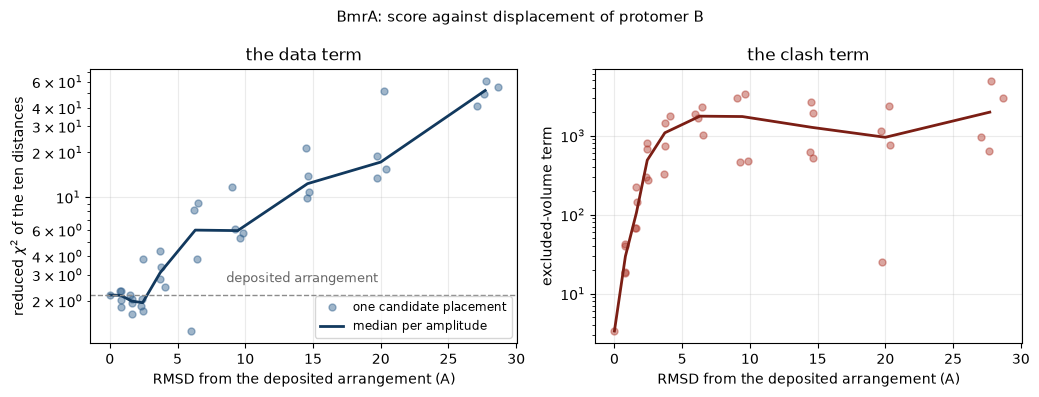

 0- 3 A off: data term x0.9, clash term x20
 3- 7 A off: data term x1.6, clash term x463
 7-12 A off: data term x2.7, clash term x521
12-22 A off: data term x6.7, clash term x284
22-40 A off: data term x23.9, clash term x592


In [9]:
medians = np.array([[np.median(scan[scan[:, 0] == a, 1]),
                     np.median(scan[scan[:, 0] == a, 2]),
                     np.median(scan[scan[:, 0] == a, 3])]
                    for a in AMPLITUDES])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
axes[0].plot(scan[:, 1], scan[:, 2], "o", color="#2E5E8B", ms=5, alpha=0.45,
             label="one candidate placement")
axes[0].plot(medians[:, 0], medians[:, 1], "-", color="#12395E", lw=2,
             label="median per amplitude")
axes[0].axhline(DEPOSITED_CHI2R, color="0.55", ls="--", lw=1)
axes[0].annotate("deposited arrangement", (scan[:, 1].max() * 0.30,
                                           DEPOSITED_CHI2R * 1.22),
                 color="0.4", fontsize=9)
axes[0].set_ylabel(r"reduced $\chi^2$ of the ten distances")
axes[0].set_title("the data term")
axes[0].legend(loc="lower right", fontsize=8.5)

axes[1].plot(scan[:, 1], scan[:, 3] + 1e-2, "o", color="#B03A2E", ms=5, alpha=0.45)
axes[1].plot(medians[:, 0], medians[:, 2] + 1e-2, "-", color="#7B1E14", lw=2)
axes[1].set_ylabel("excluded-volume term")
axes[1].set_title("the clash term")
for ax in axes:
    ax.set_yscale("log")
    ax.set_xlabel("RMSD from the deposited arrangement (A)")
    ax.grid(alpha=0.25)
fig.suptitle("BmrA: score against displacement of protomer B", fontsize=11)
fig.tight_layout()
plt.show()

for window in ((0.0, 3.0), (3.0, 7.0), (7.0, 12.0), (12.0, 22.0), (22.0, 40.0)):
    rows = scan[(scan[:, 1] >= window[0]) & (scan[:, 1] < window[1])]
    if len(rows):
        print("%2.0f-%2.0f A off: data term x%.1f, clash term x%.0f"
              % (window[0], window[1],
                 np.median(rows[:, 2]) / DEPOSITED_CHI2R,
                 np.median(rows[:, 3]) / scan[0, 3]))

The left panel is the answer to "does the network pin the structure down", and
it has two parts. Within two or three Ångström of the deposited arrangement the
data term is flat -- it even dips slightly below the deposited value, because a
6% error bar on ten distances cannot tell those placements apart, and because
the frozen clouds of the mean-position approximation are not exactly the clouds
the moved structure has. **That flat region is the resolution of this network:
about two to three Ångström, not zero.** Outside it the data term climbs
steeply, several-fold by ten Ångström and more than twentyfold by twenty, which
is what makes a search possible at all.

So do not read the floor of that curve as a goodness of fit. The
mean-position approximation is there to make tens of thousands of evaluations
affordable; the number you quote comes from a full re-scoring at the end, which
is what the last section does. And the printed table is the honest version of
the picture -- a median over four random directions per amplitude, because a
single direction can be unrepresentatively good or bad.

The right panel is the reason the search is hard, and it is specific to this
complex. BmrA's two protomers are intertwined: their transmembrane helices
cross over, so protomer B cannot be moved out of the dimer -- or back into it --
as a rigid piece without passing through protomer A. Two Ångström of
displacement already costs a hundredfold in overlap energy, and the term does
not come back down as the displacement grows, because in almost every direction
the moved protomer is still ploughing through the one that is held fixed. Only
a translation along the one axis that slides the two apart escapes it, and the
data term there is already hopeless.

So the two panels between them describe a wall: the data says where the answer
is, and the excluded volume stands between the search and it. A minimiser that
runs into that wall slides along it rather than through it, which is exactly
what the next section measures.

## The search, and how far it reaches

`IMP.bff.dock_minimize` is the local half of the engine: it applies a starting
pose, then drives the mobile bodies downhill under the distance restraints and
the excluded-volume term with conjugate gradients. (`IMP.bff.dock` is the
global half -- a Monte-Carlo or ensemble sampler over the same objective -- and
is what a production run uses; the last section says what that costs.)

Instead of one docking run, the honest experiment is a series of them from
increasingly displaced starts, which measures the radius of convergence: the
distance from which a local method still gets home. `initial_poses` hands the
run its start, and `shuffle_max_translation = 0` stops it from randomising on
top of that, so the only thing varying between rows is how far the start was.

In [10]:
params = IMP.bff.DockingParameters()
params.score_set = "all"
params.fixed_body = 0                 # chain A is the frame; chain B moves
params.n_frames = 300                 # conjugate-gradient iterations
params.shuffle_max_translation = 0.0  # the start is given, not randomised
params.mean_position_restraint = True
params.coarse_clash = False           # per-atom clash: required by olga radii
params.clash_radii_source = CLASH_RADII
params.save_trajectory = False

dock_rng = np.random.default_rng(42)
runs = []
t0 = time.time()
for amplitude in (1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 12.0):
    axis = dock_rng.standard_normal(3)
    axis /= np.linalg.norm(axis)
    step = dock_rng.standard_normal(3)
    step = amplitude * step / np.linalg.norm(step)
    start = displaced_pose(amplitude, axis, step)
    before, rmsd_before = score_pose(start)

    docked = IMP.bff.dock_minimize([PROTOMER_A, PROTOMER_B], FPS_FILE,
                                   str(WORK / ("dock_%02d" % amplitude)),
                                   params, None, start)
    after, rmsd_after = score_pose(docked.poses)
    runs.append({"amplitude": amplitude, "start": start, "docked": docked,
                 "before": before, "after": after,
                 "rmsd_before": rmsd_before, "rmsd_after": rmsd_after})
    print("start %5.2f A (chi2_r %8.2f, clash %8.1f)  ->  "
          "docked %6.2f A (chi2_r %7.2f, clash %6.2f)"
          % (rmsd_before, chi2_red(before), before.e_clash,
             rmsd_after, chi2_red(after), after.e_clash))
print("\n%d runs in %.0f s" % (len(runs), time.time() - t0))

start  0.80 A (chi2_r     2.08, clash     52.9)  ->  docked   0.27 A (chi2_r    2.10, clash   2.95)


start  1.57 A (chi2_r     2.25, clash     54.9)  ->  docked   0.34 A (chi2_r    2.11, clash   2.92)


start  2.26 A (chi2_r     3.95, clash    362.7)  ->  docked   0.29 A (chi2_r    2.11, clash   2.92)
start  3.23 A (chi2_r     3.55, clash    696.5)  ->  docked  29.43 A (chi2_r   51.13, clash   8.00)


start  4.00 A (chi2_r     4.06, clash   1098.9)  ->  docked  27.50 A (chi2_r   27.42, clash   2.71)


start  4.87 A (chi2_r     3.01, clash    360.8)  ->  docked   6.47 A (chi2_r    2.19, clash 160.33)


start  6.13 A (chi2_r     4.25, clash   1848.3)  ->  docked  20.22 A (chi2_r   30.85, clash   2.02)
start  9.80 A (chi2_r    15.45, clash   1150.7)  ->  docked  21.13 A (chi2_r   29.82, clash   1.76)

8 runs in 74 s


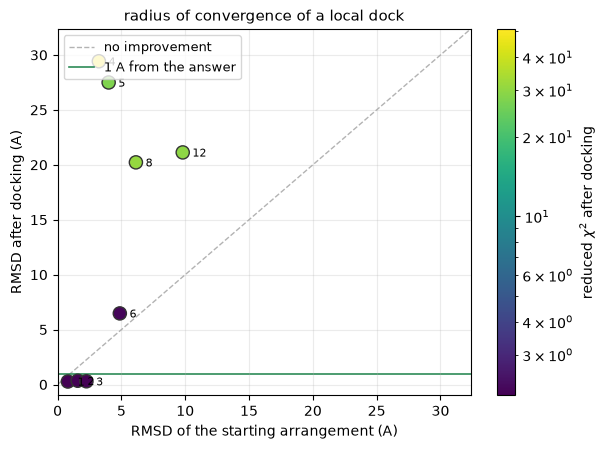

recovered (< 1 A): starts at 0.8 A, 1.6 A, 2.3 A
lost:              starts at 3.2 A, 4.0 A, 4.9 A, 6.1 A, 9.8 A


In [11]:
fig, ax = plt.subplots(figsize=(6.2, 4.6))
x = [r["rmsd_before"] for r in runs]
y = [r["rmsd_after"] for r in runs]
c = [chi2_red(r["after"]) for r in runs]
sc = ax.scatter(x, y, c=c, cmap="viridis", norm=plt.matplotlib.colors.LogNorm(),
                s=90, edgecolor="0.2", zorder=3)
for r in runs:
    ax.annotate("%.0f" % r["amplitude"],
                (r["rmsd_before"], r["rmsd_after"]),
                textcoords="offset points", xytext=(7, -3), fontsize=8)
lim = max(max(x), max(y)) * 1.1
ax.plot([0, lim], [0, lim], color="0.7", ls="--", lw=1, zorder=1,
        label="no improvement")
ax.axhline(1.0, color="#2E8B57", lw=1.2, zorder=1, label="1 A from the answer")
ax.set_xlabel("RMSD of the starting arrangement (A)")
ax.set_ylabel("RMSD after docking (A)")
ax.set_xlim(0, lim)
ax.set_ylim(-1, lim)
ax.grid(alpha=0.25)
ax.legend(loc="upper left", fontsize=9)
fig.colorbar(sc, ax=ax, label=r"reduced $\chi^2$ after docking")
ax.set_title("radius of convergence of a local dock", fontsize=11)
fig.tight_layout()
plt.show()

recovered = [r for r in runs if r["rmsd_after"] < 1.0]
lost = [r for r in runs if r["rmsd_after"] >= 1.0]
print("recovered (< 1 A): starts at %s"
      % ", ".join("%.1f A" % r["rmsd_before"] for r in recovered))
print("lost:              starts at %s"
      % ", ".join("%.1f A" % r["rmsd_before"] for r in lost))

Read the figure as two regimes, with one instructive exception.

Starts within about two and a half Ångström come back to within a few tenths of
an Ångström of the deposited arrangement. In that regime the ten distances
genuinely determine the placement, and the exercise is *refinement*: you
already have a model, and the data sharpens it and tells you by how much.

Starts beyond that mostly end twenty Ångström or more away, with a reduced
$\chi^2$ in the tens -- and, notably, with a *low* clash term. That is the wall
from the previous section. The minimiser cannot push protomer B back through
protomer A, so it slides it off the interface into a clash-free but
data-incompatible arrangement and stops there. The score says honestly that the
model is bad; the minimiser simply cannot reach the good one from there.

The exception is worth looking for in the table: one run ends a few Ångström
out with a data term as good as the correct answer's and a clash term in the
hundreds. The ten distances alone do not exclude that pose -- the excluded
volume does. This is the everyday argument for keeping a steric term in the
objective even when the measurements are what you care about, and the reason
the two terms are always reported separately rather than summed into one
number.

This is the result to carry away, and it is not a defect of the data: the
network is informative (the landscape section proved that), the *local search*
is the limitation. For an intertwined dimer like BmrA, "dock the two protomers
from scratch as rigid bodies" is not a well-posed problem to begin with -- the
assembled structure is not reachable from a separated one by rigid motion.
Where rigid-body FRET docking earns its keep is on complexes whose components
associate by a surface, as in the HIV reverse transcriptase / DNA example that
ships in `examples/structure/fret_docking.py`.

## The per-distance report

A total $\chi^2$ hides which measurement is unhappy. The per-pair table is what
you actually read after a docking run: the residual is the model minus the
data, so a positive value means the model is too long. Below are the deviations
of one run -- the hardest start that still came home -- before and after the
minimisation, and the same numbers as a network diagram, each chord coloured by
how far that pair is off.

The final model is also re-scored with the *full* accessible volumes rather than
the mean-position approximation the search ran under. That is the number to
quote.

In [12]:
# The run worth showing is the hardest start that still came home; if none
# did, the one that ended with the lowest total score.
recovered_runs = [r for r in runs if r["rmsd_after"] < 1.0]
best = (max(recovered_runs, key=lambda r: r["rmsd_before"]) if recovered_runs
        else min(runs, key=lambda r: r["after"].score))
print("showing the run that started %.2f A off and ended %.2f A off"
      % (best["rmsd_before"], best["rmsd_after"]))

docked_pdb = best["docked"].best_pdbs[0]
docked_A = split_chain(docked_pdb, "A", WORK / "docked_A.pdb")
docked_B = split_chain(docked_pdb, "B", WORK / "docked_B.pdb")
full = IMP.bff.score_structures([docked_A, docked_B], FPS_FILE, "all",
                                False, 6.0, "", CLASH_RADII, 1.0)

print("\nchi2_red   mean-position (what the search minimised): %.3f"
      % chi2_red(best["after"]))
print("chi2_red   full volumes  (what to quote):              %.3f" % chi2_red(full))
print("chi2_red   deposited arrangement, full volumes:        %.3f"
      % chi2_red(reference[CLASH_RADII]))

before_model = {q.name: q.distance_model for q in best["before"].pairs}
after_model = {q.name: q.distance_model for q in full.pairs}
print("\n%-14s %9s %9s %9s %9s %9s"
      % ("pair", "measured", "start", "dev", "docked", "dev"))
for p in PAIRS:
    n = pair_name(p)
    m = measured[p]
    print("%-14s %9.2f %9.2f %+9.2f %9.2f %+9.2f"
          % (n, m, before_model[n], before_model[n] - m,
             after_model[n], after_model[n] - m))

showing the run that started 2.26 A off and ended 0.29 A off

chi2_red   mean-position (what the search minimised): 2.109


chi2_red   full volumes  (what to quote):              0.982
chi2_red   deposited arrangement, full volumes:        0.755

pair            measured     start       dev    docked       dev
A410_B220          30.94     33.43     +2.49     30.38     -0.56
A60_B290           34.00     27.89     -6.11     30.69     -3.31
A470_B220          38.27     34.47     -3.80     37.33     -0.94
A220_B520          45.51     40.57     -4.93     42.88     -2.62
A60_B60            46.86     37.25     -9.61     45.28     -1.58
A520_B350          53.18     45.04     -8.13     47.69     -5.49
A350_B410          55.85     58.84     +3.00     57.65     +1.81
A520_B520          58.72     52.18     -6.54     55.44     -3.28
A470_B290          54.90     55.32     +0.42     59.00     +4.10
A350_B60           79.55     76.88     -2.66     78.89     -0.65


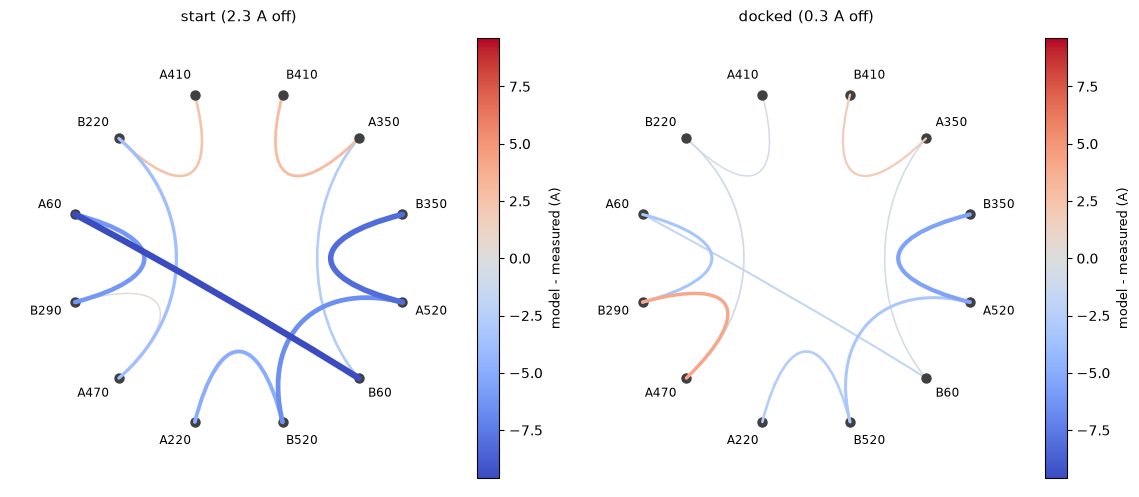

mean |deviation|: start 4.77 A -> docked 2.43 A


In [13]:
chords = [(site_name(p[0], p[1]), site_name(p[2], p[3])) for p in PAIRS]
start_dev = {c: before_model[pair_name(p)] - measured[p]
             for c, p in zip(chords, PAIRS)}
final_dev = {c: after_model[pair_name(p)] - measured[p]
             for c, p in zip(chords, PAIRS)}
limit = max(max(abs(v) for v in start_dev.values()),
            max(abs(v) for v in final_dev.values()))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2))
ws.circle_plot(chords, start_dev, ax=axes[0], vmax=limit,
               title="start (%.1f A off)" % best["rmsd_before"])
ws.circle_plot(chords, final_dev, ax=axes[1], vmax=limit,
               title="docked (%.1f A off)" % best["rmsd_after"])
fig.tight_layout()
plt.show()

print("mean |deviation|: start %.2f A -> docked %.2f A"
      % (np.mean([abs(v) for v in start_dev.values()]),
         np.mean([abs(v) for v in final_dev.values()])))

## Looking at it

Three arrangements: the deposited dimer, the start of that run, and where the
docking put it. Chain A is in the same place in all three by construction --
it is body 0, held fixed -- so everything you see move is protomer B.

The viewer loads Mol* from a CDN, so it needs internet access from the browser.
Nothing above depends on it.

In [14]:
start_pdb = WORK / "start.pdb"
IMP.bff.apply_poses(assembly, best["start"])
IMP.atom.write_pdb(assembly.get_root(), str(start_pdb))
IMP.bff.apply_poses(assembly, REFERENCE_POSES)

widest = max(PAIRS, key=lambda p: helper_distance[p])
ws.show([
    {"title": "deposited (6R72 A+B), with the volumes of %s and %s"
              % (site_name(widest[0], widest[1]), site_name(widest[2], widest[3])),
     "structure": ws.protein_for_view(closed_dimer),
     "clouds": [
         {"pdb": ws.av_pdb(volume[(widest[0], widest[1])]),
          "colour": ws.DONOR_COLOUR, "label": site_name(widest[0], widest[1])},
         {"pdb": ws.av_pdb(volume[(widest[2], widest[3])]),
          "colour": ws.ACCEPTOR_COLOUR, "label": site_name(widest[2], widest[3])},
     ]},
    {"title": "start of the best run (%.1f A off)" % best["rmsd_before"],
     "structure": ws.protein_for_view(start_pdb)},
    {"title": "docked (%.1f A off, chi2_red %.2f)"
              % (best["rmsd_after"], chi2_red(full)),
     "structure": ws.protein_for_view(docked_pdb)},
], height=430)

## What a production run looks like, and what this one left out

Everything above fits in a few minutes because every choice was made to keep it
there. A real determination differs in the following ways.

**Global sampling instead of local descent.** `IMP.bff.dock` runs the same
objective under a sampler chosen by `DockingParameters.sampler` --
`"metropolis"`, or the ensemble movers `"stretch"`, `"slice"`, `"de"`, which do
not need their step sizes tuned. A production run is `n_frames` in the hundreds
with `mc_steps` of ten or more, simulated annealing on, `shuffle_max_translation`
large enough to forget where it started, and `n_best` set so the twenty
best-scoring poses are written out. That is tens of thousands of evaluations
per run, minutes to hours, and it is repeated from many independent starts --
*the spread of the resulting scores is the result, not the best of them.*

**Error bars on the pose.** `IMP.bff.fps_bootstrap` perturbs the measurements
within their error bars and re-docks, once per replica, so the scatter of the
replicas around the parent gives the precision of the placement in Ångström.
`IMP.bff.estimate_docking_errors` is the lighter version of the same idea. A
docked structure without one of these is a point estimate with no error bar.

**Volumes resampled in context.** `DockingParameters.refine_av_cycles` re-runs
the accessible-volume calculation at the docked pose and minimises again, which
matters exactly where the mean-position approximation is weakest: a dye whose
occlusion by the partner subunit changes as the subunit moves.

**A command line, not a notebook.** All of the above is `imp_bff dock`; see
`imp_bff dock --help` and `src/imp/CommandLineDock.cpp`.

And the four things this notebook is honest about having simplified:

1. **The data is synthetic** -- generated from the very structure the docking
   was asked to find, with Gaussian noise and nothing else. Real networks carry
   dye artefacts, labelling perturbations and state mixtures, and a real fit
   is judged against those, not against a known answer.
2. **The protomers were treated as rigid.** BmrA's nucleotide-binding domains
   move relative to its transmembrane domains between the two states, so a real
   analysis of this system is a flexible problem, and a rigid dock can at best
   answer "which state", which is the screening question the notebook ran.
3. **Only the local search was exercised.** The runs above are conjugate
   gradients from a given start; no Monte-Carlo sampling was run at all. The
   failures past a couple of Ångström are failures of local descent against an
   excluded-volume wall, not of the data, and a global sampler is the thing to
   reach for next.
4. **One noise draw, one network.** The whole analysis rests on a single
   realisation of the measurement error and a single choice of ten pairs.
   Repeating it over draws is what turns "the docking recovered the structure"
   into a statement with an error bar on it.

In [15]:
print("total notebook runtime: %.0f s" % (time.time() - T_START))

total notebook runtime: 89 s
